# Perceptron Model implementation using Perceptron Learning Algorithm
Based on [CS6910/CS7015 - Deep Learning Course](https://www.cse.iitm.ac.in/~miteshk/CS6910.html) lectures _(L1, L2)_ by [Prof. Mitesh M. Khapra](https://www.cse.iitm.ac.in/~miteshk/)

## Setup
Install the required libraries.
- `ipython` - To run this notebook in VSCode setup.
- `jupyter` - To open and run this notebook.
- `pandas` - Used to load and manipulate data.
- `matplotlib` - Used for all the plots in this notebook.

In [1]:
pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Import statements.
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Notebook inputs
Set the following variables to get started:
1. `epochs` - Number of training epochs. Defaults to 10.
2. `data_file_name` - CSV data file name.

In [8]:
# Folder paths.
data_folder_path = "data"
saved_models_folder_path = "saved_models"

# Interactive inputs.
epochs = 10

# 'AND', 'identity', 'NAND', 'NOR', 'NOT', 'null', 'OR', 'transfer', 'XNOR' and 'XOR' available.
data_file_name = "OR.csv"
model_file_name = f"{data_file_name.split('.')[0]}_perceptron.pkl"

In [9]:
# Prepare full path.
data_file_path = os.path.join("..", data_folder_path, data_file_name)
model_file_path = os.path.join("..", saved_models_folder_path, model_file_name)

# Print model save path and name.
print(f"Model will be saved to: {model_file_path}")

Model will be saved to: ..\saved_models\OR_perceptron.pkl


In [10]:
print(f"INFO: Loading dataset from '{data_file_path}' ...")
try:
    data = pd.read_csv(data_file_path)
except FileNotFoundError:
    print(f"ERROR: Data file '{data_file_path}' not found.")
    exit()

print(f"INFO: Dataset loaded. Shape: {data.shape}")

# Separate features (X) and labels (y).
X = data.drop("y", axis=1).to_numpy(dtype=np.float16)  # Drop the label column to get the features.
y = data["y"].to_numpy(dtype=np.float16)  # Get the label column.

input_size = X.shape[1]

INFO: Loading dataset from '..\data\OR.csv' ...
INFO: Dataset loaded. Shape: (4, 3)


## Visualize dataset
For 2D data we will plot a simple scatter plot to visualize and think about the probable best fit linear division.


INFO: Visualizing Input Data ...


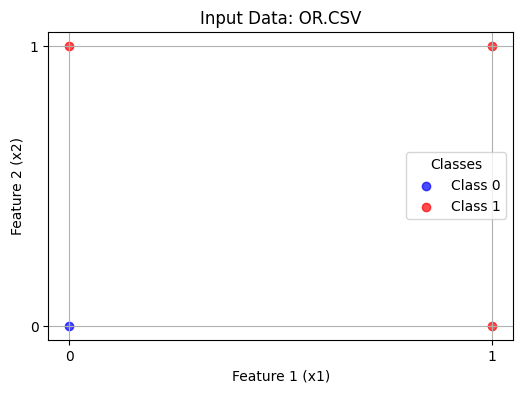

In [11]:
if input_size == 2:
    plt.figure(figsize=(6, 4))
    plt.title(f"Input Data: {data_file_name.upper()}")
    plt.grid(True)

    print("\nINFO: Visualizing Input Data ...")
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c="blue", label="Class 0", alpha=0.7)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c="red", label="Class 1", alpha=0.7)

    plt.legend(title="Classes")
    plt.xlabel("Feature 1 (x1)")
    plt.ylabel("Feature 2 (x2)")
    plt.xticks(np.arange(0, 2, step=1))
    plt.yticks(np.arange(0, 2, step=1))
    plt.show()


## Step function - Heaviside

In [13]:
class HeavisideStepActivation:
    """
    Implements the Heaviside step function.

    `f(x) = 1 if x >= 0`
    `f(x) = 0 if x < 0`

    ![](https://upload.wikimedia.org/wikipedia/commons/thumb/d/d9/Dirac_distribution_CDF.svg/300px-Dirac_distribution_CDF.svg.png)
    """

    @staticmethod
    def activate(x: float) -> float:
        """
        Applies the Heaviside step function.

        Args:
            x (float): The input value (e.g., weighted sum).

        Returns:
            float: 0 or 1.
        """

        return float(x >= 0.0)


## Perceptron Class
This is our Perceptron implementation. Here the idea is to use Heaviside step activation. Also, we can plot the current learnings of the perceptron during each epoch and the error history after the training is compelete.

In [15]:
class Perceptron:
    """
    A single-layer perceptron implementation.
    Capable of fitting over linearly separable datasets. Fits the model using the Perceptron Learning Algorithm (PLA).
    Uses a heaviside step activation function.

    We use the following notation throughout the code:
    - Inputs: x = [x1, x2, ..., xn]
    - Weights: w = [w0, w1, w2, ..., wn] where w0 is the bias weight. We initialize the weights as a zero vector.
    - Weighted sum: z = w0 + w1*x1 + w2*x2 + ... + wn*xn
    - Output: y = activate(z)
    """

    def __init__(self, input_size: int) -> None:
        # We start with random set of weights. For simplicity, we initialize them to zero here.
        self.weights = np.zeros(input_size + 1)  # +1 for the bias weight

        # We use the heaviside step activation function.
        self._activate = HeavisideStepActivation.activate

    def fit(self, train_data, labels, epochs: int = 10, verbose: bool = True) -> None:
        """
        Train the perceptron using the Perceptron Learning Algorithm (PLA).
        We use the heaviside step activation function here.
        Optionally, visualize the decision boundary after each epoch for 2D data and the error history after training.

        Args:
            train_data: The input training data (features).
            labels: The corresponding labels for the training data.
            epochs: Number of epochs to train the model.
            verbose: If True, show visualizations during training.

        Returns:
            None
        """

        error_history = []
        visualize = verbose and train_data.shape[1] == 2
        if visualize:
            plt.ion()

        print(f"INFO: Starting training (Epochs: {epochs}) ...")
        for epoch in range(epochs):
            num_errors = 0
            for x, label in zip(train_data, labels):
                # Make a prediction.
                prediction = self.predict(x)

                # Calculate the error.
                error = self.loss(prediction, label)
                if error != 0:
                    num_errors += 1

                    # Update weights based on the prediction error.
                    self.update_weights(x, error)

            print(f"DEBUG: Epoch {epoch + 1}/{epochs}, Number of errors: {num_errors}")

            if visualize:
                plot_title = f"Epoch: {epoch + 1}/{epochs} | Errors: {num_errors}"
                # Record the number of errors for this epoch for visualization.
                error_history.append(num_errors)
                self.plot_decision_boundary(train_data, labels, title=plot_title)
                plt.pause(0.5)

            if num_errors == 0:
                print("INFO: Training complete - Early Stoppage! - no errors found.")
                if visualize:
                    plt.pause(0.5)
                break

        # Plot the error history after training.
        if visualize:
            plt.ioff()
            plt.figure(figsize=(8, 4))
            plt.plot(range(1, len(error_history) + 1), error_history, marker="o")
            plt.title("Perceptron Training Progress (Errors per Epoch)")
            plt.xlabel("Epoch")
            plt.ylabel("Number of Misclassifications")
            plt.xticks(np.arange(1, len(error_history) + 1, step=1))
            plt.yticks(np.arange(0, len(train_data) + 1, step=1))
            plt.grid(True)
            plt.show()

    def load(self, file_path: str) -> None:
        """
        Load the model weights from a file. We use pickle for simplicity.

        Args:
            file_path: The path to the file from which the weights will be loaded.

        Returns:
            None
        """

        with open(file_path, "rb") as file:
            self.weights = pickle.load(file)

    def loss(self, predicted, actual) -> float:
        """
        Simple difference loss function.
        `loss = actual - predicted`

        Args:
            predicted: The predicted output from the model.
            actual: The actual target output.

        Returns:
            The difference between actual and predicted values.
        """

        return actual - predicted

    def predict(self, inputs) -> float:
        """
        Make a prediction for the given inputs.
        The prediction is made by calculating the weighted sum of inputs and applying the activation function.
        `prediction = activate(w0*1 + w1*x1 + ... + wn*xn)`

        Args:
            inputs: The input features for which to make the prediction.

        Returns:
            The predicted output (0 or 1).
        """

        # Calculate the weighted sum i.e. dot product of the inputs and weights.
        weighted_sum = self.weights[0] + np.dot(self.weights[1:], inputs)

        # Apply the activation function to get the final prediction.
        return self._activate(weighted_sum)

    def save(self, file_path: str) -> None:
        """
        Save the model weights to a file. We use pickle for simplicity.

        Args:
            file_path: The path to the file where the weights will be saved.

        Returns:
            None
        """

        with open(file_path, "wb") as file:
            pickle.dump(self.weights, file)

    def update_weights(self, inputs, error) -> None:
        """
        Update the weights based on the prediction error.
        The logic is based on the Perceptron Learning Rule:
        If error >= 0:
            w0 = w0 + 1
            wi = wi + xi for all i
        Else:
            w0 = w0 - 1
            wi = wi - xi for all i
        Args:
            inputs: The input features.
            error: The prediction error (actual - predicted).

        Returns:
            None
        """

        if error >= 0:
            # Update bias weight.
            # Bias weight update rule: w0 = w0 + 1. Since bias input is always 1.
            self.weights[0] += 1

            # Update other weights. Note that we are performing vector addition here.
            # Weight update rule: w = w + x
            self.weights[1:] += inputs
        else:
            # Update bias weight.
            # Bias weight update rule: w0 = w0 - 1. Since bias input is always 1.
            self.weights[0] -= 1

            # Update other weights. Note that we are performing vector subtraction here.
            # Weight update rule: w = w - x
            self.weights[1:] -= inputs

    def plot_decision_boundary(self, X, y, title=None) -> None:
        """
        Plots the decision boundary for 2D data.
        This function will only work if the data has 2 features.

        Args:
            X: The input data (features).
            y: The corresponding labels.
            title: Optional title for the plot.

        Returns:
            None
        """

        plt.clf()

        # Get weights.
        w0, w1, w2 = self.weights

        # Plot data points.
        plt.scatter(X[y == 0, 0], X[y == 0, 1], color="blue", label="Class 0", alpha=0.7)
        plt.scatter(X[y == 1, 0], X[y == 1, 1], color="red", label="Class 1", alpha=0.7)

        # Calculate the decision line.
        x1_min = np.min(X[:, 0]) - 1
        x1_max = np.max(X[:, 0]) + 1
        x_values = np.linspace(x1_min, x1_max, 50)

        if w2 != 0:
            y_values = (-w1 * x_values - w0) / w2
            plt.plot(x_values, y_values, color="green", linestyle="--", label="Decision Boundary")
        elif w1 != 0:
            vertical_line_x = -w0 / w1
            plt.axvline(x=vertical_line_x, color="green", linestyle="--", label="Decision Boundary")

        plt.title(title or "Perceptron Decision Boundary (2D)")
        plt.xlabel("Feature 1 (x1)")
        plt.ylabel("Feature 2 (x2)")
        plt.legend()
        plt.grid(True)
        plt.xlim(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5)
        plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)


## Training

In [16]:
# Instantiate the perceptron model.
# Input size is the number of features in the dataset.
model = Perceptron(input_size)

INFO: Starting training (Epochs: 10) ...
DEBUG: Epoch 1/10, Number of errors: 2


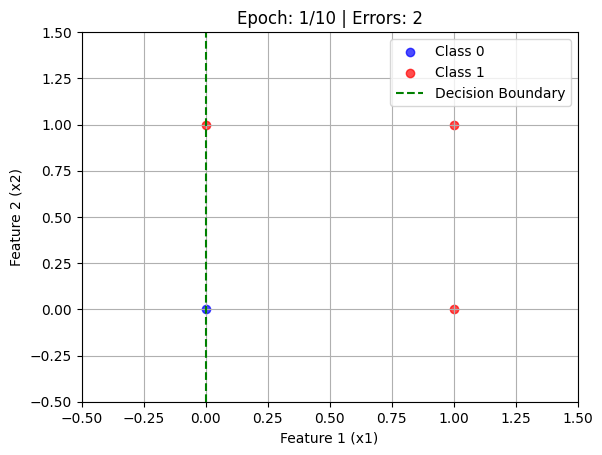

DEBUG: Epoch 2/10, Number of errors: 2


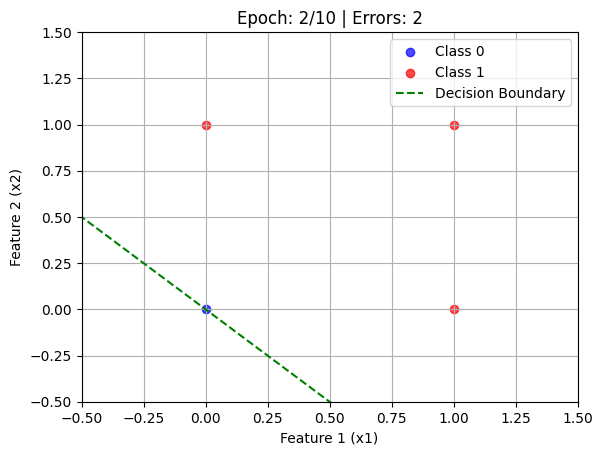

DEBUG: Epoch 3/10, Number of errors: 1


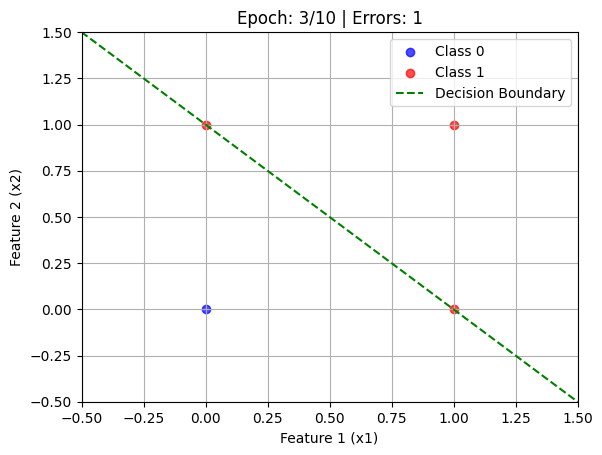

DEBUG: Epoch 4/10, Number of errors: 0


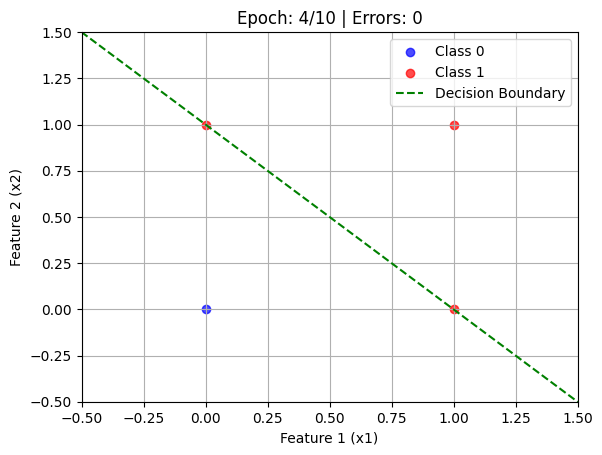

INFO: Training complete - Early Stoppage! - no errors found.


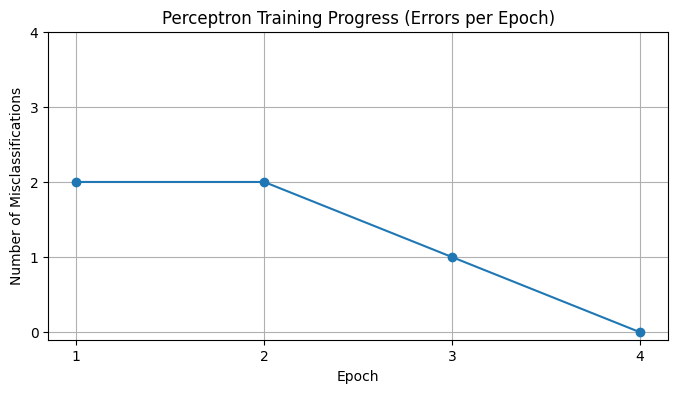


DEBUG: Weights: [-1.  1.  1.] (w0 is bias weight)


In [17]:
# Train the model.
model.fit(X, y, epochs=epochs, verbose=True)
print(f"\nDEBUG: Weights: {model.weights} (w0 is bias weight)")

## Test
For this trivial example we do not split the data into train - test set and hence the testing is done on the train data itself.

In [18]:
# Test the model.
print(f"\nINFO: Testing on all data ...")
correct_count = 0
for inputs, label in zip(X, y):
    prediction = model.predict(inputs)
    if label == prediction:
        correct_count += 1
    print(f"Input: {inputs}, Expectation: {label}, Prediction: {prediction}")

print(f"\nINFO: Accuracy: {correct_count / len(y) * 100:.2f}%")


INFO: Testing on all data ...
Input: [0. 0.], Expectation: 0.0, Prediction: 0.0
Input: [1. 0.], Expectation: 1.0, Prediction: 1.0
Input: [0. 1.], Expectation: 1.0, Prediction: 1.0
Input: [1. 1.], Expectation: 1.0, Prediction: 1.0

INFO: Accuracy: 100.00%


## Save the trained model

In [22]:
# Save the trained model.
print(f"\nDEBUG: Saving trained model to '{model_file_path}' ...")
model.save(model_file_path)
print("DEBUG: Model saved successfully.")


DEBUG: Saving trained model to '../saved_models/OR_perceptron.pkl' ...
DEBUG: Model saved successfully.


## Make Inference
We can use the saved trained model to make inference on the data.

In [20]:
model = Perceptron(input_size)

# Load the trained model.
print(f"\nDEBUG: Loading trained model '{model_file_path}' ...")
model.load(model_file_path)
print(f"INFO: Model loaded successfully. Weights: {model.weights} (w0 is bias weight)")



DEBUG: Loading trained model '..\saved_models\OR_perceptron.pkl' ...
INFO: Model loaded successfully. Weights: [-1.  1.  1.] (w0 is bias weight)


In [21]:
# Test the model.
print(f"\nINFO: Testing on all data ...")
correct_count = 0
for inputs, label in zip(X, y):
    prediction = model.predict(inputs)
    if label == prediction:
        correct_count += 1
    print(f"Input: {inputs}, Expectation: {label}, Prediction: {prediction}")

print(f"\nINFO: Accuracy: {correct_count / len(y) * 100:.2f}%")



INFO: Testing on all data ...
Input: [0. 0.], Expectation: 0.0, Prediction: 0.0
Input: [1. 0.], Expectation: 1.0, Prediction: 1.0
Input: [0. 1.], Expectation: 1.0, Prediction: 1.0
Input: [1. 1.], Expectation: 1.0, Prediction: 1.0

INFO: Accuracy: 100.00%
